In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

df = pd.read_csv('employment_preprocessed.csv')

In [11]:
X = df.drop(columns=['Employed', 'id'], errors='ignore')
y = df['Employed']
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

 1. Train Random Forest Model

In [12]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

 2. Train XGBoost Model

In [13]:
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

 3. Print Full Classification Reports (Precision, Recall, F1-Score)

In [14]:
print("="*50)
print("=== RANDOM FOREST REPORT ===")
print(classification_report(y_test, y_pred_rf))

print("="*50)
print("=== XGBOOST REPORT ===")
print(classification_report(y_test, y_pred_xgb))

=== RANDOM FOREST REPORT ===
              precision    recall  f1-score   support

           0       0.75      0.74      0.74      6814
           1       0.78      0.79      0.78      7879

    accuracy                           0.76     14693
   macro avg       0.76      0.76      0.76     14693
weighted avg       0.76      0.76      0.76     14693

=== XGBOOST REPORT ===
              precision    recall  f1-score   support

           0       0.79      0.73      0.76      6814
           1       0.78      0.84      0.81      7879

    accuracy                           0.79     14693
   macro avg       0.79      0.78      0.78     14693
weighted avg       0.79      0.79      0.79     14693



 4. Plot Top 10 Feature Importances (XGBoost)

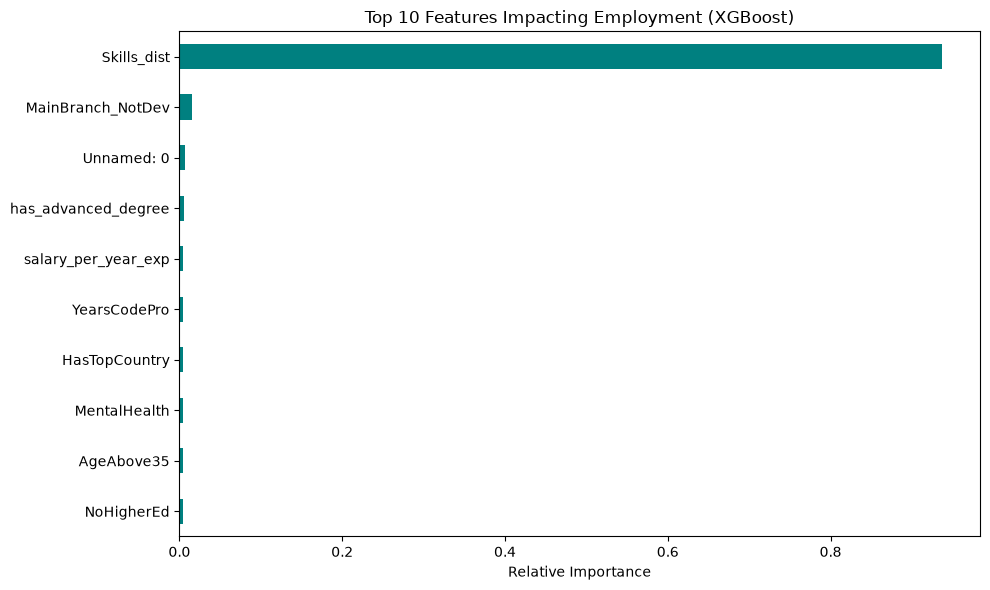

In [15]:
plt.figure(figsize=(10, 6))
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Features Impacting Employment (XGBoost)')
plt.xlabel('Relative Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

 Create a dummy dataframe with zeros matching the model features

In [16]:
import pandas as pd

new_candidate = pd.DataFrame(0, index=[0], columns=X.columns)


new_candidate['Skills_dist'] = 2       # skills (0 , 1 , 2)
new_candidate['YearsCodePro'] = 4         # years of professional experience
new_candidate['AgeAbove35'] = 1           # Under 35 years old (0 , 1)
new_candidate['has_advanced_degree'] = 1   # Holds a master/PhD (0 ,1)


prediction = xgb_model.predict(new_candidate)[0]
probability = xgb_model.predict_proba(new_candidate)[0][1] * 100


print("=== Manual Candidate Prediction ===")
if prediction == 1:
    print(f"Status: EMPLOYED ✅ | Probability: {probability:.1f}%")
else:
    print(f"Status: NOT EMPLOYED ❌ | Probability: {100 - probability:.1f}%")

=== Manual Candidate Prediction ===
Status: EMPLOYED ✅ | Probability: 93.0%
